In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Advertising.csv to Advertising.csv


In [7]:
df = pd.read_csv("Advertising.csv")
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [8]:
print(df.shape)

print(df.columns)

df.info()

(200, 5)
Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [9]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [10]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [11]:
print(df.columns.tolist())

['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']


In [12]:
X = df.drop('Sales', axis=1)

y = df['Sales']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [15]:
y_pred = model.predict(X_test)

In [16]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 1.465060105010293


In [17]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 1.7885761008659673


In [18]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.898648915141708


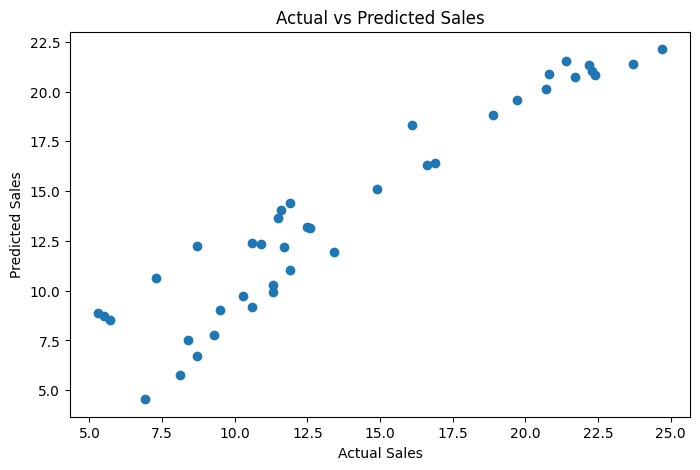

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [20]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(importance)

      Feature  Coefficient
0  Unnamed: 0     0.000644
1          TV     0.044718
2       Radio     0.189251
3   Newspaper     0.003046


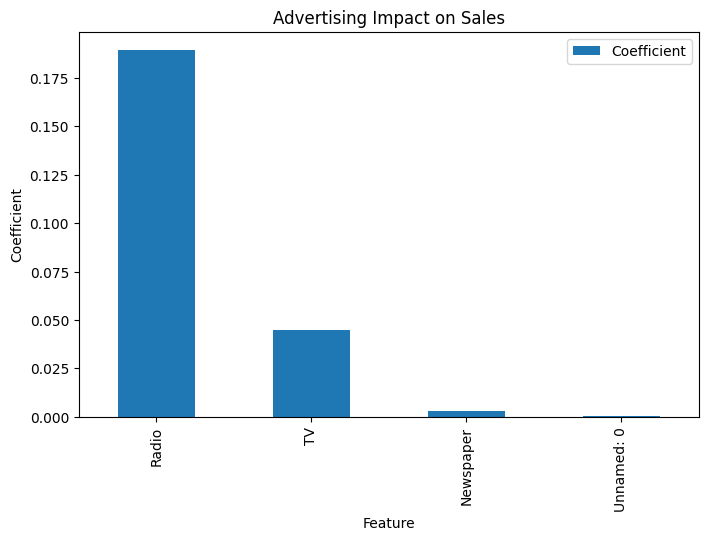

In [21]:
importance.sort_values(
    by='Coefficient',
    ascending=False
).plot(
    x='Feature',
    y='Coefficient',
    kind='bar',
    figsize=(8,5)
)

plt.title("Advertising Impact on Sales")

plt.ylabel("Coefficient")

plt.show()

In [22]:
print(df.corr(numeric_only=True))

            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000
